# Agent Eval Dashboard

LangGraph Sandbox Agent 的评估可视化仪表板。

本 Notebook 读取 `logs/*.json` 文件，生成精简版 Eval 可视化报告：
1. 模式总览对比（Token / 轮数 / 耗时 / 收敛率）
2. Token 增长曲线
3. 详细数据表
4. Context Mode 深度分析
5. 跨模型对比
6. 模型效率象限图

In [1]:
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置 matplotlib 中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 配置路径
LOGS_DIR = Path("logs")

def extract_int(pattern: str, text: str, default: int = 0) -> int:
    """从文本中提取整数"""
    match = re.search(pattern, text)
    return int(match.group(1)) if match else default

def extract_last_int(pattern: str, text: str, default: int = 0) -> int:
    """从文本中提取最后一个匹配的整数"""
    matches = re.findall(pattern, text)
    return int(matches[-1]) if matches else default

def extract_float(pattern: str, text: str, default: float = 0.0) -> float:
    """从文本中提取浮点数"""
    match = re.search(pattern, text)
    return float(match.group(1)) if match else default

def extract_str(pattern: str, text: str, default: str = "") -> str:
    """从文本中提取字符串"""
    match = re.search(pattern, text)
    return match.group(1) if match else default

def parse_log_file(filepath: Path) -> list[dict]:
    """
    解析单个日志文件为 flat records
    兼容新旧两种日志格式：
    - 新格式：result 中有 metrics 字段（Phase 1 之后）
    - 旧格式：从 stdout 用正则提取指标
    Phase 2: 新增 model 字段支持多模型横评
    """
    data = json.loads(filepath.read_text("utf-8"))
    mode = data["mode"]
    model = data.get("model", "(unknown)")
    config = data["config"]
    records = []
    for r in data["results"]:
        stdout = r.get("stdout", "")
        metrics = r.get("metrics", {})
        
        # 提取 round_token_history
        round_token_history = r.get("round_token_history", [])
        
        # 计算累计 token（优先从 round_token_history，其次从 stdout 正则）
        rth_total = sum(rd.get("total_tokens", 0) for rd in round_token_history)
        stdout_total = extract_last_int(r"cum\(total=(\d+)\)", stdout)
        
        # 从 stdout 提取轮次数（如果 round_token_history 为空）
        round_matches = re.findall(r"\[ROUND (\d+)\]", stdout)
        stdout_round_count = int(round_matches[-1]) + 1 if round_matches else 0
        
        # 从 stdout 解析每轮 token 明细（用于生成 token 增长曲线）
        if not round_token_history and stdout:
            for m in re.finditer(
                r"\[ROUND (\d+)\].*?round\(prompt=(\d+), completion=(\d+), total=(\d+)\)\s*cum\(total=(\d+)\)",
                stdout, re.DOTALL
            ):
                round_token_history.append({
                    "round": int(m.group(1)),
                    "prompt_tokens": int(m.group(2)),
                    "completion_tokens": int(m.group(3)),
                    "total_tokens": int(m.group(4)),
                    "cumulative_tokens": int(m.group(5)),
                })

        # 从 stdout 提取 stop_reason
        stop_reason = (
            metrics.get("stop_reason")
            or extract_str(r"stop_reason=([a-z_]+)", stdout)
        )
        
        execution_count = (
            metrics.get("execution_count")
            or extract_int(r"execution_count=(\d+)", stdout)
        )

        record = {
            "mode": mode,
            "model": model,
            "task": r["task"][:80],
            "task_index": r.get("index", 0),
            "return_code": r.get("return_code", 0),
            "execution_count": execution_count,
            "stop_reason": stop_reason,
            "elapsed_seconds": metrics.get("elapsed_seconds") or extract_float(r"elapsed_seconds=([\d.]+)", stdout),
            "duration_seconds": r.get("duration_seconds", 0),
            "total_tokens": metrics.get("llm_total_tokens") or rth_total or stdout_total,
            "prompt_tokens": metrics.get("llm_prompt_tokens", 0),
            "completion_tokens": metrics.get("llm_completion_tokens", 0),
            "max_prompt_tokens": metrics.get("max_prompt_tokens") or extract_int(r"max_prompt_tokens:\s*(\d+)", stdout),
            "round_count": len(round_token_history) or stdout_round_count,
            "round_token_history": round_token_history,
            "task_success": metrics.get("task_success", stop_reason == "no_tool_calls"),
            "compression_ratio": metrics.get("compression_ratio", 0.0),
            "fetch_hit_count": metrics.get("fetch_hit_count", 0),
            "per_round_llm_latency": metrics.get("per_round_llm_latency", []),
            "per_round_tool_latency": metrics.get("per_round_tool_latency", []),
            "avg_llm_latency": np.mean(metrics.get("per_round_llm_latency")) if metrics.get("per_round_llm_latency") else None,
            "avg_tool_latency": np.mean(metrics.get("per_round_tool_latency")) if metrics.get("per_round_tool_latency") else None,
            "config_max_exec": config.get("max_executions"),
            "config_timeout": config.get("total_timeout"),
            "log_file": filepath.name,
        }
        records.append(record)
    return records

# 加载所有日志文件
all_records = []
for log_file in sorted(LOGS_DIR.glob("*.json")):
    try:
        records = parse_log_file(log_file)
        all_records.extend(records)
        print(f"✓ Loaded: {log_file.name} ({len(records)} records)")
    except Exception as e:
        print(f"✗ Failed to load {log_file.name}: {e}")

# 创建 DataFrame
df = pd.DataFrame(all_records)

if df.empty:
    print("\n⚠️ 没有加载到任何数据，请确保 logs/ 目录下有 .json 日志文件")
else:
    print(f"\n📊 总计加载 {len(df)} 条记录，包含以下模式:")
    print(df["mode"].value_counts())
    models = df["model"].unique()
    if len(models) > 1:
        print(f"\n🤖 包含 {len(models)} 个模型: {', '.join(models)}")
    print(f"\n   平均轮次: {df['round_count'].mean():.1f}, 平均Token: {df['total_tokens'].mean():.0f}")

✓ Loaded: baseline_5_20260315_064457.json (5 records)
✓ Loaded: baseline_fix_test_20260315_073206.json (2 records)
✓ Loaded: baseline_fix_test_20260315_073316.json (2 records)
✓ Loaded: baseline_flash_v3.json (7 records)
✓ Loaded: baseline_minimal_20260315_060026.json (2 records)
✓ Loaded: baseline_plus_v3.json (7 records)
✓ Loaded: baseline_subset5_20260315_032634.json (5 records)
✓ Loaded: cm_fix_test_20260315_062931.json (2 records)
✓ Loaded: cm_flash_v3.json (7 records)
✓ Loaded: cm_plus_v3.json (7 records)
✓ Loaded: context_mode_5_20260315_065056.json (5 records)
✓ Loaded: context_mode_minimal_20260315_060108.json (2 records)
✓ Loaded: context_mode_subset5_20260314_181129.json (5 records)
✓ Loaded: context_mode_subset5_20260315_032854.json (5 records)
✓ Loaded: context_mode_v2_subset5_20260314_115446.json (5 records)
✓ Loaded: naive_5_20260315_064101.json (5 records)
✓ Loaded: native_fix_test_20260315_063425.json (2 records)
✓ Loaded: native_minimal_20260315_055909.json (2 records

## 1. 模式总览对比

对比三种模式（Native / Baseline / Context Mode）的核心指标。

📈 模式总览对比:
             total_tokens          execution_count     elapsed_seconds         \
                     mean      sum            mean max            mean    std   
mode                                                                            
baseline         34678.83  1040365            4.10  25           43.73  47.82   
context_mode     32366.29  1229919            5.39  25           53.00  49.41   
native           29133.33   262200            4.33  14           34.36  30.41   

             round_count task_success       compression_ratio fetch_hit_count  
                    mean          sum  mean              mean            mean  
mode                                                                           
baseline            4.97           21  0.70              0.05            0.00  
context_mode        6.82           32  0.84              0.01            0.18  
native              5.33            9  1.00              0.00            0.00  


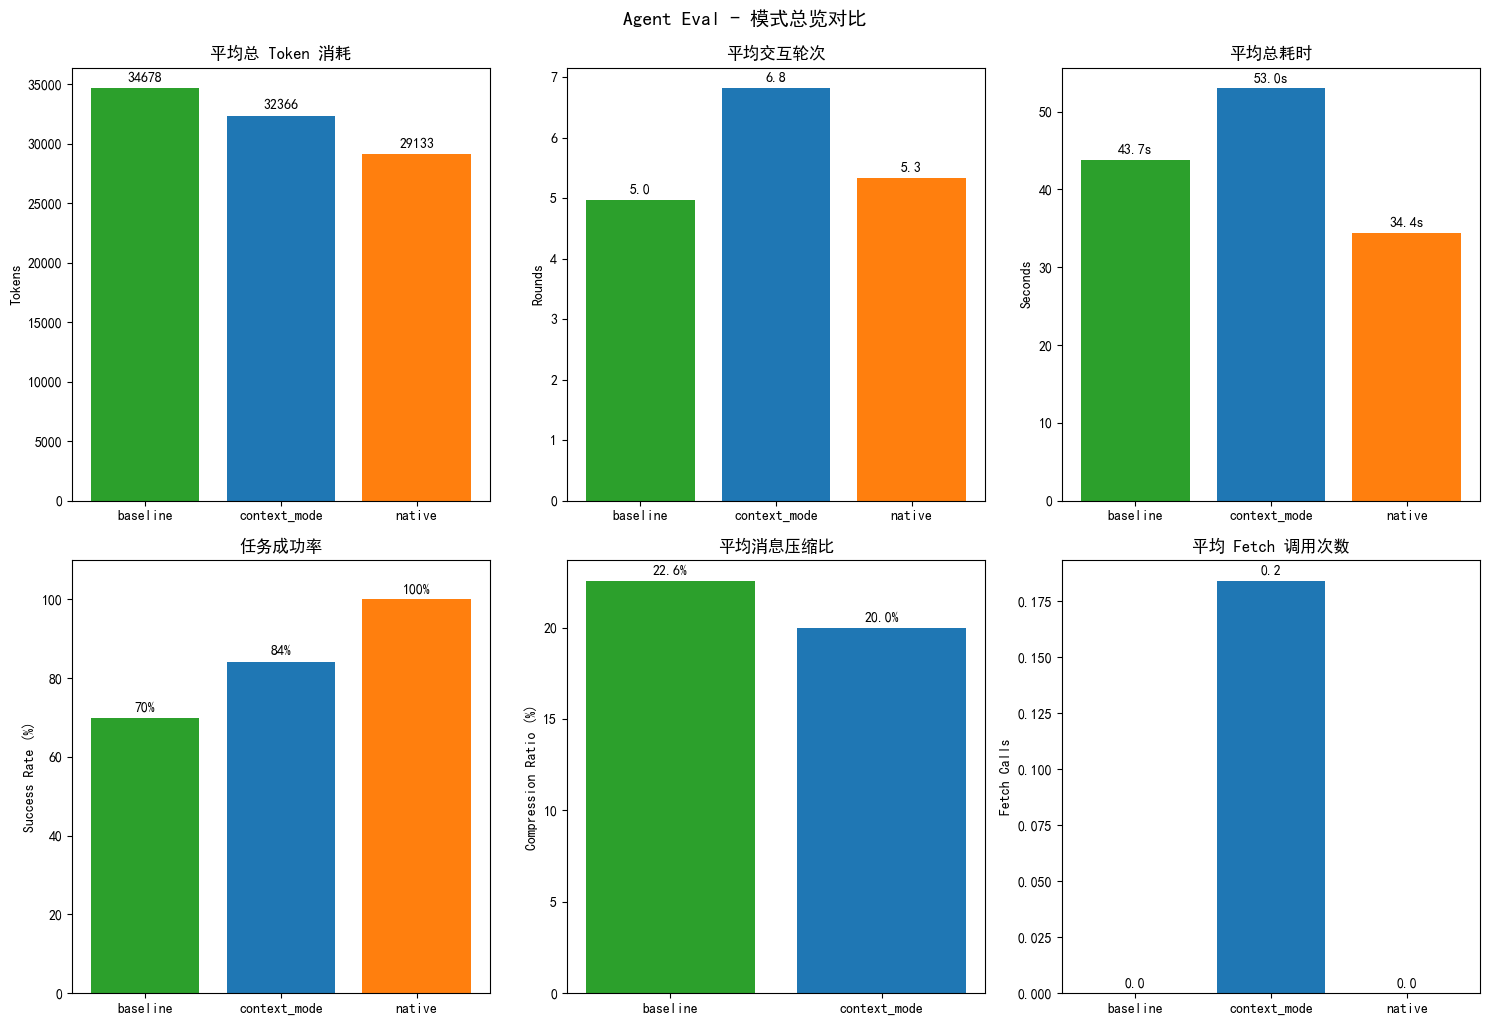

In [2]:
if not df.empty:
    # 按模式聚合
    mode_summary = df.groupby("mode").agg({
        "total_tokens": ["mean", "sum"],
        "execution_count": ["mean", "max"],
        "elapsed_seconds": ["mean", "std"],
        "round_count": "mean",
        "task_success": ["sum", "mean"],
        "compression_ratio": "mean",
        "fetch_hit_count": "mean",
    }).round(2)
    
    print("📈 模式总览对比:")
    print(mode_summary)
    
    # 可视化对比
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    modes = df["mode"].unique()
    colors = {"native": "#ff7f0e", "baseline": "#2ca02c", "context_mode": "#1f77b4"}
    
    # 1. 平均总 Token
    ax = axes[0, 0]
    mode_tokens = df.groupby("mode")["total_tokens"].mean()
    bars = ax.bar(mode_tokens.index, mode_tokens.values, color=[colors.get(m, "gray") for m in mode_tokens.index])
    ax.set_title("平均总 Token 消耗")
    ax.set_ylabel("Tokens")
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
    
    # 2. 平均交互轮次
    ax = axes[0, 1]
    mode_rounds = df.groupby("mode")["round_count"].mean()
    bars = ax.bar(mode_rounds.index, mode_rounds.values, color=[colors.get(m, "gray") for m in mode_rounds.index])
    ax.set_title("平均交互轮次")
    ax.set_ylabel("Rounds")
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
    
    # 3. 平均耗时
    ax = axes[0, 2]
    mode_time = df.groupby("mode")["elapsed_seconds"].mean()
    bars = ax.bar(mode_time.index, mode_time.values, color=[colors.get(m, "gray") for m in mode_time.index])
    ax.set_title("平均总耗时")
    ax.set_ylabel("Seconds")
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}s', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
    
    # 4. 任务成功率
    ax = axes[1, 0]
    mode_success = df.groupby("mode")["task_success"].mean() * 100
    bars = ax.bar(mode_success.index, mode_success.values, color=[colors.get(m, "gray") for m in mode_success.index])
    ax.set_title("任务成功率")
    ax.set_ylabel("Success Rate (%)")
    ax.set_ylim(0, 110)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
    
    # 5. 平均消息压缩比
    ax = axes[1, 1]
    mode_compression = df[df["compression_ratio"] > 0].groupby("mode")["compression_ratio"].mean() * 100
    if not mode_compression.empty:
        bars = ax.bar(mode_compression.index, mode_compression.values, color=[colors.get(m, "gray") for m in mode_compression.index])
        ax.set_title("平均消息压缩比")
        ax.set_ylabel("Compression Ratio (%)")
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
    else:
        ax.text(0.5, 0.5, "无压缩数据", ha='center', va='center', transform=ax.transAxes)
        ax.set_title("平均消息压缩比")
    
    # 6. 平均 Fetch 调用次数
    ax = axes[1, 2]
    mode_fetch = df.groupby("mode")["fetch_hit_count"].mean()
    bars = ax.bar(mode_fetch.index, mode_fetch.values, color=[colors.get(m, "gray") for m in mode_fetch.index])
    ax.set_title("平均 Fetch 调用次数")
    ax.set_ylabel("Fetch Calls")
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
    
    plt.tight_layout()
    plt.suptitle("Agent Eval - 模式总览对比", fontsize=14, y=1.02)
    plt.show()

## 2. Token 增长曲线

展示每个任务的 `round_token_history`，对比三种模式的 Token 累积增长情况。

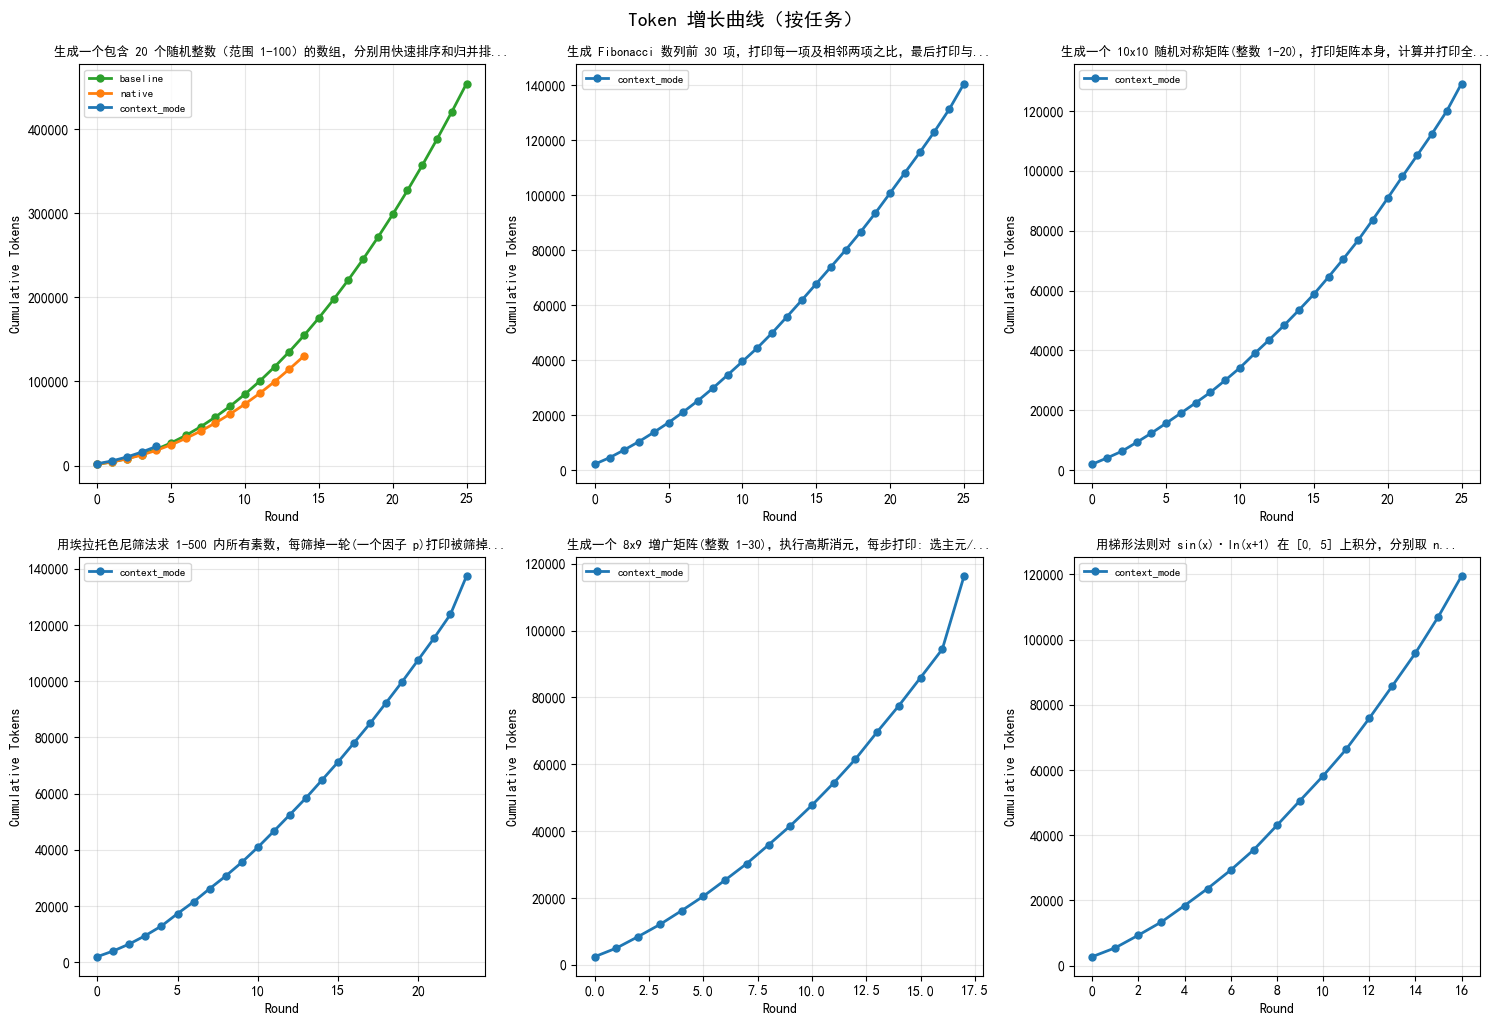

In [3]:
if not df.empty:
    # 只保留有 round_token_history 数据的行
    df_with_rth = df[df["round_token_history"].apply(lambda x: len(x) > 0)]
    
    # 去重：同一 task+mode 只保留 round_count 最大的那条（最完整数据）
    if not df_with_rth.empty:
        df_with_rth = df_with_rth.sort_values("round_count", ascending=False).drop_duplicates(subset=["task", "mode"], keep="first")
    
    # 选择最多 6 个有数据的任务
    sample_tasks = df_with_rth["task"].unique()[:6]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    mode_colors = {"native": "#ff7f0e", "baseline": "#2ca02c", "context_mode": "#1f77b4"}
    
    for idx, task in enumerate(sample_tasks):
        ax = axes[idx]
        task_df = df_with_rth[df_with_rth["task"] == task]
        
        for _, row in task_df.iterrows():
            history = row["round_token_history"]
            if history:
                rounds = [h.get("round", i) for i, h in enumerate(history)]
                # 使用 cumulative_tokens（stdout 解析），否则手动累计
                if "cumulative_tokens" in history[0]:
                    cum_tokens = [h["cumulative_tokens"] for h in history]
                else:
                    cum_tokens = [sum(h.get("total_tokens", 0) for h in history[:i+1]) for i in range(len(history))]
                ax.plot(rounds, cum_tokens, marker='o', label=row["mode"],
                        color=mode_colors.get(row["mode"], "gray"), linewidth=2, markersize=5)
        
        ax.set_title(task[:40] + "..." if len(task) > 40 else task, fontsize=9)
        ax.set_xlabel("Round")
        ax.set_ylabel("Cumulative Tokens")
        if ax.get_legend_handles_labels()[1]:
            ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # 隐藏多余 subplot
    for idx in range(len(sample_tasks), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle("Token 增长曲线（按任务）", fontsize=14, y=1.02)
    plt.show()
else:
    print("⚠️ 无数据")

## 3. 详细数据表

展示所有任务的详细指标。

In [8]:
if not df.empty:
    # 选择关键列展示
    display_cols = ["task", "mode", "execution_count", "round_count", "total_tokens",
                  "elapsed_seconds", "task_success", "stop_reason",
                  "compression_ratio", "fetch_hit_count"]
    
    display_df = df[display_cols].copy()
    display_df["task"] = display_df["task"].str[:50]
    display_df["compression_ratio"] = display_df["compression_ratio"].apply(lambda x: f"{x:.2%}" if x else "-")
    display_df["task_success"] = display_df["task_success"].apply(lambda x: "✓" if x else "✗")
    display_df["elapsed_seconds"] = display_df["elapsed_seconds"].round(2)
    
    # 按模式分组展示
    for mode in display_df["mode"].unique():
        print(f"\n{'='*80}")
        print(f"模式: {mode.upper()}")
        print(f"{'='*80}")
        mode_data = display_df[display_df["mode"] == mode].drop("mode", axis=1)
        print(mode_data.to_string(index=False))


模式: BASELINE
                                              task  execution_count  round_count  total_tokens  elapsed_seconds task_success    stop_reason compression_ratio  fetch_hit_count
计算 Fibonacci 数列第 30 项的值，以及 F(30)/F(29) 的比值，返回结果保留1                1            2          2897             9.62            ✓  no_tool_calls                 -                0
生成一个 5x6 增广矩阵(整数 1-20)，执行高斯消元求解。打印：初始矩阵（5行）、每一步的主元                3            4         12150            27.20            ✓  no_tool_calls                 -                0
用梯形法则对 sin(x)·ln(x+1) 在 [0, 5] 上积分，分别取 n=10,50,200                1            2          3642             9.78            ✓  no_tool_calls                 -                0
生成一个包含 20 个随机整数（范围 1-100）的数组，分别用快速排序和归并排序对其进行排序。对快               25           26        453936           158.26            ✗ max_executions                 -                0
生成一个 8x8 的随机迷宫（用 0 表示通路，1 表示墙），保证起点 (0,0) 和终点 (7,7                9           10         52826            62.43

## 4. Context Mode 深度分析

专门分析 Context Mode 的上下文压缩效果。

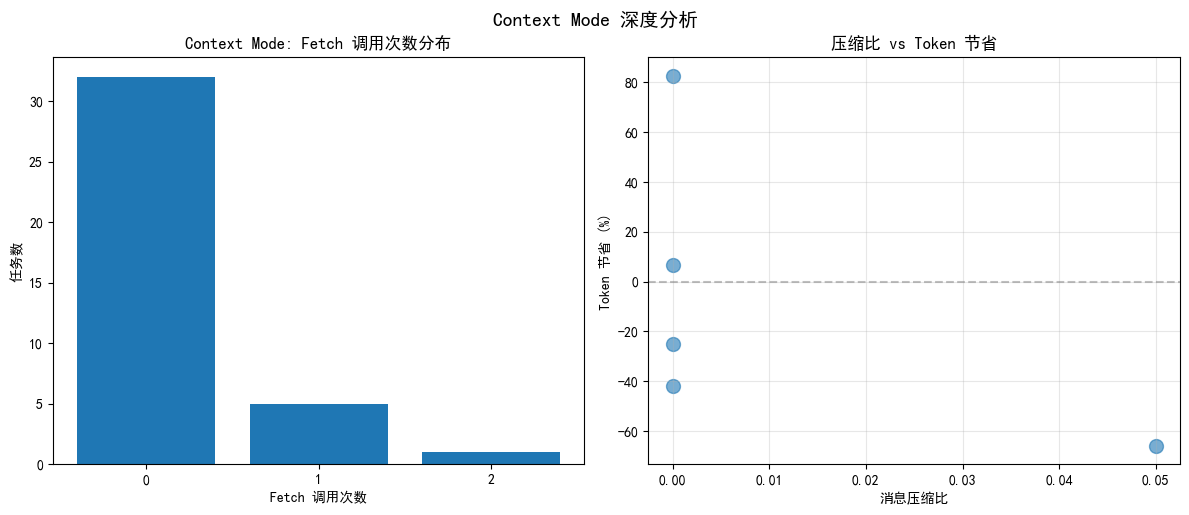


📊 Context Mode 统计:
  - 平均 fetch 调用: 0.18 次/任务
  - 消息压缩比: 0.53%
  - 任务成功率: 84.2%


In [9]:
if not df.empty:
    cm_df = df[df["mode"] == "context_mode"]
    
    if not cm_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # 1. Fetch 调用次数分布
        ax = axes[0]
        fetch_counts = cm_df["fetch_hit_count"].value_counts().sort_index()
        ax.bar(fetch_counts.index.astype(str), fetch_counts.values, color="#1f77b4")
        ax.set_title("Context Mode: Fetch 调用次数分布")
        ax.set_xlabel("Fetch 调用次数")
        ax.set_ylabel("任务数")
        
        # 2. 压缩比 vs Token 节省（与 Native 对比）
        ax = axes[1]
        native_df = df[df["mode"] == "native"]
        if not native_df.empty:
            # 计算每个任务的 Token 节省
            for task in cm_df["task"].unique():
                task_cm = cm_df[cm_df["task"] == task]
                task_native = native_df[native_df["task"] == task]
                if not task_native.empty:
                    cm_tokens = task_cm["total_tokens"].mean()
                    native_tokens = task_native["total_tokens"].mean()
                    savings = (native_tokens - cm_tokens) / native_tokens * 100 if native_tokens > 0 else 0
                    compression = task_cm["compression_ratio"].mean()
                    ax.scatter(compression, savings, color="#1f77b4", alpha=0.6, s=100)
            
            ax.set_xlabel("消息压缩比")
            ax.set_ylabel("Token 节省 (%)")
            ax.set_title("压缩比 vs Token 节省")
            ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, "无 Native 模式数据对比", ha='center', va='center', transform=ax.transAxes)
            ax.set_title("压缩比 vs Token 节省")
        
        plt.tight_layout()
        plt.suptitle("Context Mode 深度分析", fontsize=14, y=1.02)
        plt.show()
        
        # 打印 Context Mode 统计
        print("\n📊 Context Mode 统计:")
        print(f"  - 平均 fetch 调用: {cm_df['fetch_hit_count'].mean():.2f} 次/任务")
        print(f"  - 消息压缩比: {cm_df['compression_ratio'].mean():.2%}")
        print(f"  - 任务成功率: {cm_df['task_success'].mean():.1%}")
    else:
        print("⚠️ 没有 Context Mode 数据")

## 5. 跨模型对比

不同 LLM 在同一 benchmark 和模式下的 Token / 轮次 / 成功率对比。
如果只有一个模型的数据，此 section 会自动跳过。

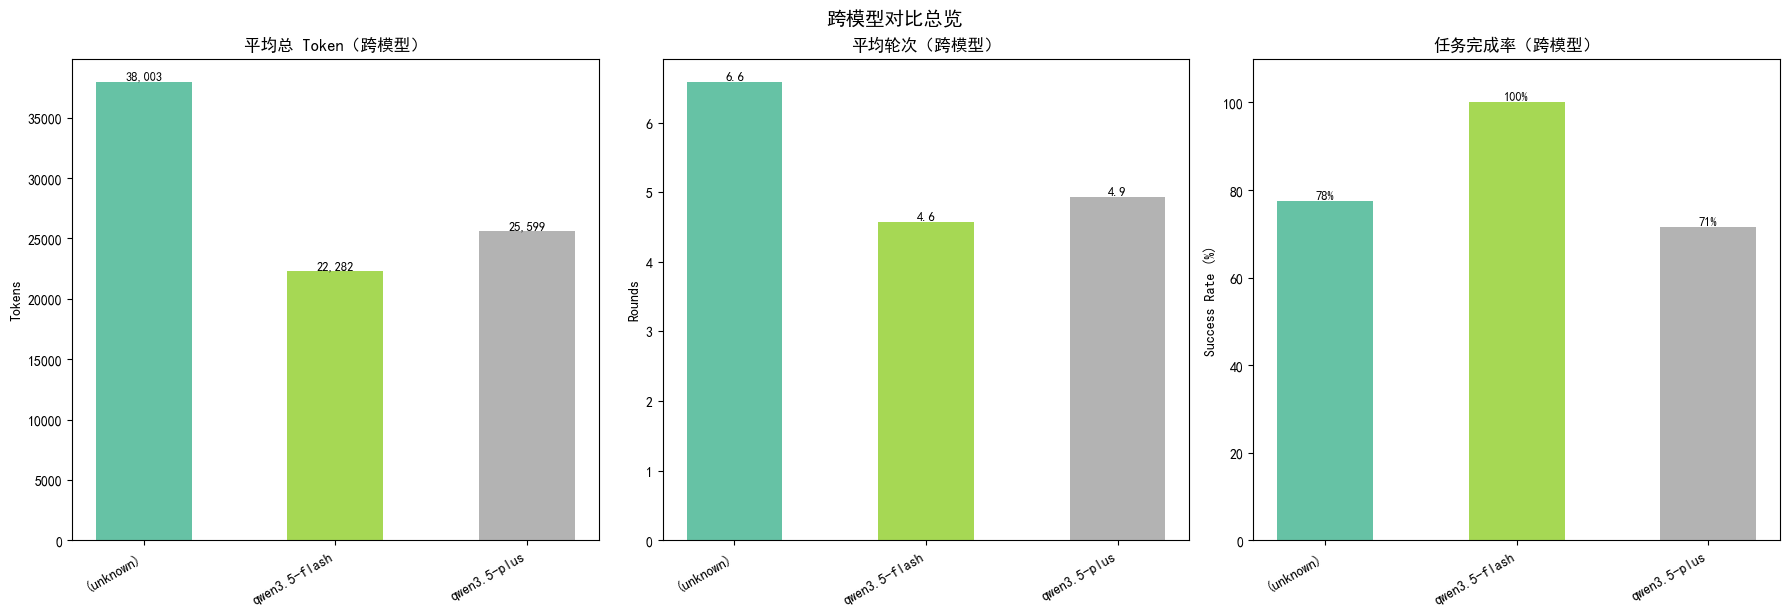

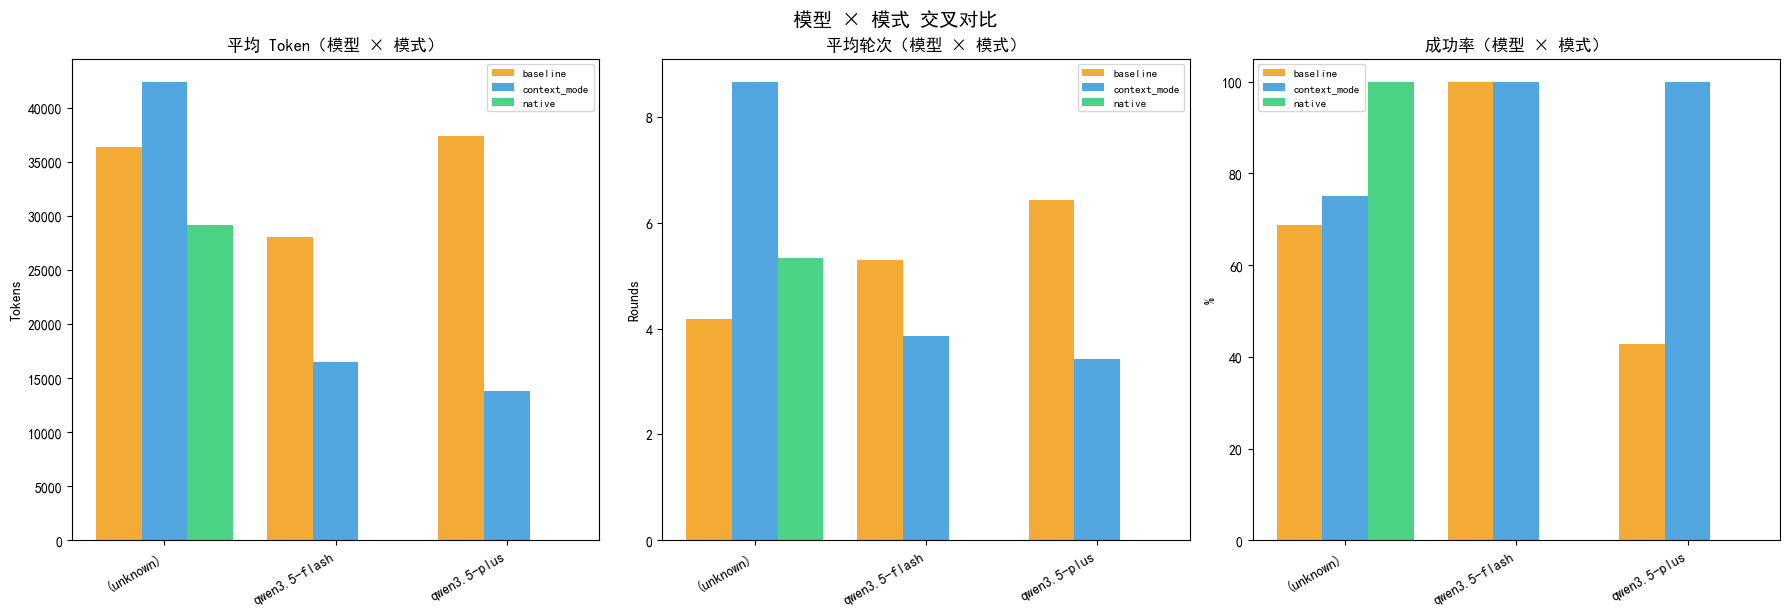

✅ 跨模型对比图表已生成


In [10]:
# 跨模型对比：分组柱状图 — 同一任务 × 不同 model → tokens / rounds / success
if not df.empty and df["model"].nunique() > 1:
    models = sorted(df["model"].unique())
    modes = sorted(df["mode"].unique())
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 按 model 汇总
    model_summary = df.groupby("model").agg(
        avg_tokens=("total_tokens", "mean"),
        avg_rounds=("round_count", "mean"),
        success_rate=("task_success", "mean"),
    ).reset_index()
    
    x = np.arange(len(model_summary))
    width = 0.5
    
    # 1. 平均 Token
    ax = axes[0]
    bars = ax.bar(x, model_summary["avg_tokens"], width, color=plt.cm.Set2(np.linspace(0, 1, len(model_summary))))
    ax.set_xticks(x)
    ax.set_xticklabels(model_summary["model"], rotation=30, ha="right")
    ax.set_title("平均总 Token（跨模型）")
    ax.set_ylabel("Tokens")
    for bar, val in zip(bars, model_summary["avg_tokens"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:,.0f}",
                ha="center", va="bottom", fontsize=9)
    
    # 2. 平均轮数
    ax = axes[1]
    bars = ax.bar(x, model_summary["avg_rounds"], width, color=plt.cm.Set2(np.linspace(0, 1, len(model_summary))))
    ax.set_xticks(x)
    ax.set_xticklabels(model_summary["model"], rotation=30, ha="right")
    ax.set_title("平均轮次（跨模型）")
    ax.set_ylabel("Rounds")
    for bar, val in zip(bars, model_summary["avg_rounds"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.1f}",
                ha="center", va="bottom", fontsize=9)
    
    # 3. 成功率
    ax = axes[2]
    bars = ax.bar(x, model_summary["success_rate"] * 100, width, color=plt.cm.Set2(np.linspace(0, 1, len(model_summary))))
    ax.set_xticks(x)
    ax.set_xticklabels(model_summary["model"], rotation=30, ha="right")
    ax.set_title("任务完成率（跨模型）")
    ax.set_ylabel("Success Rate (%)")
    ax.set_ylim(0, 110)
    for bar, val in zip(bars, model_summary["success_rate"] * 100):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.0f}%",
                ha="center", va="bottom", fontsize=9)
    
    plt.tight_layout()
    plt.suptitle("跨模型对比总览", fontsize=14, y=1.02)
    plt.show()
    
    # 分模式 × 模型 交叉对比
    cross = df.groupby(["model", "mode"]).agg(
        avg_tokens=("total_tokens", "mean"),
        avg_rounds=("round_count", "mean"),
        success_rate=("task_success", "mean"),
    ).reset_index()
    
    if len(modes) > 1:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        x = np.arange(len(models))
        bar_width = 0.8 / len(modes)
        mode_colors = {"native": "#2ecc71", "baseline": "#f39c12", "context_mode": "#3498db"}
        
        for metric_idx, (metric, title, ylabel) in enumerate([
            ("avg_tokens", "平均 Token（模型 × 模式）", "Tokens"),
            ("avg_rounds", "平均轮次（模型 × 模式）", "Rounds"),
            ("success_rate", "成功率（模型 × 模式）", "Rate"),
        ]):
            ax = axes[metric_idx]
            for mode_idx, mode in enumerate(modes):
                mode_data = cross[cross["mode"] == mode]
                vals = []
                for m in models:
                    row = mode_data[mode_data["model"] == m]
                    v = row[metric].values[0] if len(row) > 0 else 0
                    vals.append(v * 100 if metric == "success_rate" else v)
                offset = (mode_idx - len(modes)/2 + 0.5) * bar_width
                bars = ax.bar(x + offset, vals, bar_width, 
                             label=mode, color=mode_colors.get(mode, f"C{mode_idx}"), alpha=0.85)
            ax.set_xticks(x)
            ax.set_xticklabels(models, rotation=30, ha="right")
            ax.set_title(title)
            ax.set_ylabel("%" if metric == "success_rate" else ylabel)
            ax.legend(fontsize=8)
        
        plt.tight_layout()
        plt.suptitle("模型 × 模式 交叉对比", fontsize=14, y=1.02)
        plt.show()
    
    print("✅ 跨模型对比图表已生成")
else:
    if not df.empty:
        print(f"ℹ️ 当前仅有 1 个模型 ({df['model'].iloc[0]})，跳过跨模型对比。")
        print("   运行多模型横评后此 section 将自动生成图表：")
        print("   python main.py --mode context_mode --model qwen-plus --task-file ... --log-file logs/cm_qwen.json")
        print("   python main.py --mode context_mode --model gpt-4o-mini --task-file ... --log-file logs/cm_gpt4o.json")

## 6. 模型效率象限图

散点图：x=总Token, y=任务完成率, 每个点=model×mode 组合。
验证 Eval 框架的模型无关性 — 无论使用哪个 LLM，Context Mode 都能有效降低 Token 消耗。

C:\Users\陈开元\AppData\Local\Temp\ipykernel_33076\2015190677.py:67: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) SimHei.
  plt.tight_layout()
d:\Code\my-sandbox-demo\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


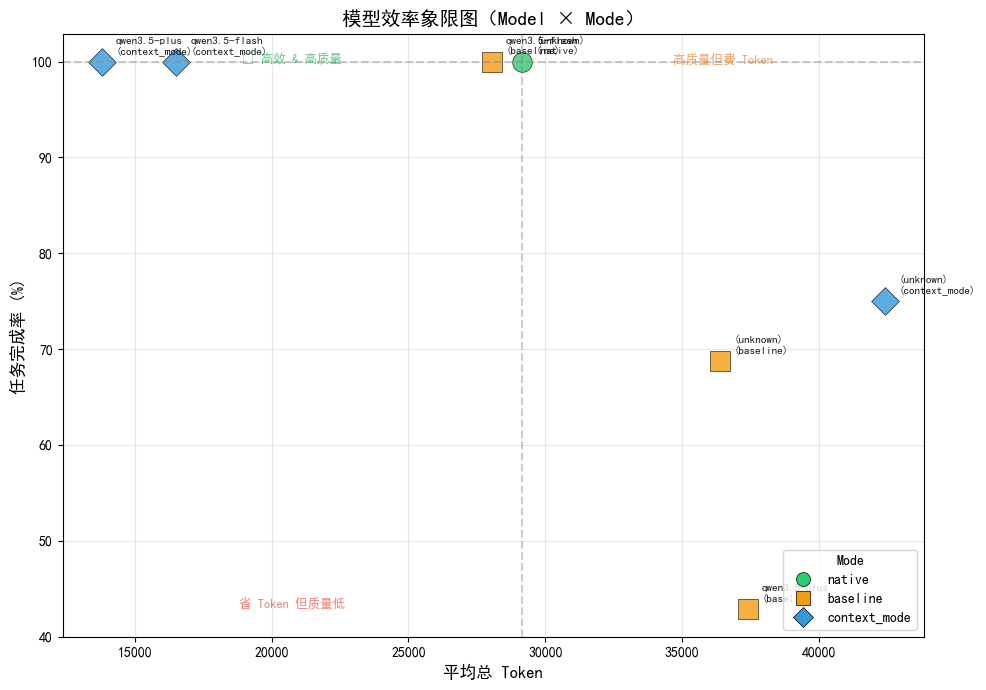

✅ 效率象限图已生成 — 左上角⭐区域为最优组合（低 Token + 高成功率）


In [11]:
# 模型效率象限图: x=平均总Token, y=任务完成率, 点=model×mode
if not df.empty and df["model"].nunique() > 1:
    cross = df.groupby(["model", "mode"]).agg(
        avg_tokens=("total_tokens", "mean"),
        success_rate=("task_success", "mean"),
        count=("task_index", "count"),
    ).reset_index()
    
    mode_markers = {"native": "o", "baseline": "s", "context_mode": "D"}
    mode_colors = {"native": "#2ecc71", "baseline": "#f39c12", "context_mode": "#3498db"}
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    for _, row in cross.iterrows():
        marker = mode_markers.get(row["mode"], "o")
        color = mode_colors.get(row["mode"], "gray")
        ax.scatter(
            row["avg_tokens"],
            row["success_rate"] * 100,
            s=200,
            marker=marker,
            color=color,
            alpha=0.8,
            edgecolors="black",
            linewidth=0.5,
        )
        ax.annotate(
            f'{row["model"]}\n({row["mode"]})',
            (row["avg_tokens"], row["success_rate"] * 100),
            textcoords="offset points",
            xytext=(10, 5),
            fontsize=8,
            alpha=0.9,
        )
    
    # 绘制象限线（中位数分割）
    median_tokens = cross["avg_tokens"].median()
    median_success = cross["success_rate"].median() * 100
    ax.axvline(x=median_tokens, color="gray", linestyle="--", alpha=0.4)
    ax.axhline(y=median_success, color="gray", linestyle="--", alpha=0.4)
    
    # 象限标注
    x_range = ax.get_xlim()
    y_range = ax.get_ylim()
    ax.text(x_range[0] + (median_tokens - x_range[0]) * 0.5, y_range[1] - 3,
            "⭐ 高效 & 高质量", ha="center", fontsize=9, color="#27ae60", alpha=0.7)
    ax.text(x_range[1] - (x_range[1] - median_tokens) * 0.5, y_range[1] - 3,
            "高质量但费 Token", ha="center", fontsize=9, color="#e67e22", alpha=0.7)
    ax.text(x_range[0] + (median_tokens - x_range[0]) * 0.5, y_range[0] + 3,
            "省 Token 但质量低", ha="center", fontsize=9, color="#e74c3c", alpha=0.7)
    
    ax.set_xlabel("平均总 Token", fontsize=12)
    ax.set_ylabel("任务完成率 (%)", fontsize=12)
    ax.set_title("模型效率象限图（Model × Mode）", fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # 图例：模式
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker=v, color="w", markerfacecolor=mode_colors[k],
               markersize=10, label=k, markeredgecolor="black", markeredgewidth=0.5)
        for k, v in mode_markers.items()
        if k in cross["mode"].values
    ]
    ax.legend(handles=legend_elements, title="Mode", loc="lower right")
    
    plt.tight_layout()
    plt.show()
    
    print("✅ 效率象限图已生成 — 左上角⭐区域为最优组合（低 Token + 高成功率）")
else:
    if not df.empty:
        print("ℹ️ 需要至少 2 个模型的数据才能生成效率象限图。")
        print("   多模型横评命令示例：")
        print("   python main.py --mode context_mode --model qwen-turbo --task-file experiment_tasks/benchmark_tasks_subset5.txt --log-file logs/cm_turbo.json")
        print("   python main.py --mode context_mode --model gpt-4o-mini --base-url https://api.openai.com/v1 --api-key sk-xxx --task-file experiment_tasks/benchmark_tasks_subset5.txt --log-file logs/cm_gpt4o.json")